# Analiza audio signala u Pythonu

U ovom dijelu projekta provodi se osnovna analiza audio signala korištenjem programskog jezika Python i biblioteka za numeričku obradu podataka.

Cilj ovog koraka je upoznati strukturu audio zapisa i prikazati signal u vremenskoj domeni. Audio datoteka učitava se iz WAV formata, nakon čega se pretvara u niz numeričkih vrijednosti koje predstavljaju amplitudu signala kroz vrijeme.

Dobiveni signal zatim se vizualizira pomoću grafa koji prikazuje promjenu amplitude u funkciji vremena. Ovakav prikaz naziva se vremenski prikaz (waveform) i predstavlja osnovni način promatranja audio signala prije provođenja daljnjih analiza.

In [15]:
import numpy as np, matplotlib.pyplot as plt
import wave

## Učitavanje i prikaz audio signala

Audio datoteka učitava se pomoću Python biblioteke `wave`, koja omogućuje čitanje podataka iz WAV formata. Iz datoteke se dohvaćaju osnovni parametri signala kao što su:

- broj kanala (mono ili stereo),
- frekvencija uzorkovanja (sample rate),
- ukupan broj uzoraka signala.

Signal se zatim pretvara u numerički niz korištenjem biblioteke `numpy`. Svaki element niza predstavlja amplitudu audio signala u određenom trenutku vremena.

Ako je audio zapis stereo, signal se pretvara u mono tako da se koristi samo jedan kanal. Time se pojednostavljuje daljnja analiza signala.

Na kraju se generira graf koji prikazuje promjenu amplitude signala kroz vrijeme, što omogućuje vizualni uvid u strukturu audio zapisa.

Za prvi primjer ćemo koristiti audio snimku konstantnog tona A4 koji je 440 hz. Znajući to možemo provjeriti ispravnost waveforma i fft grafa.

5.0  s


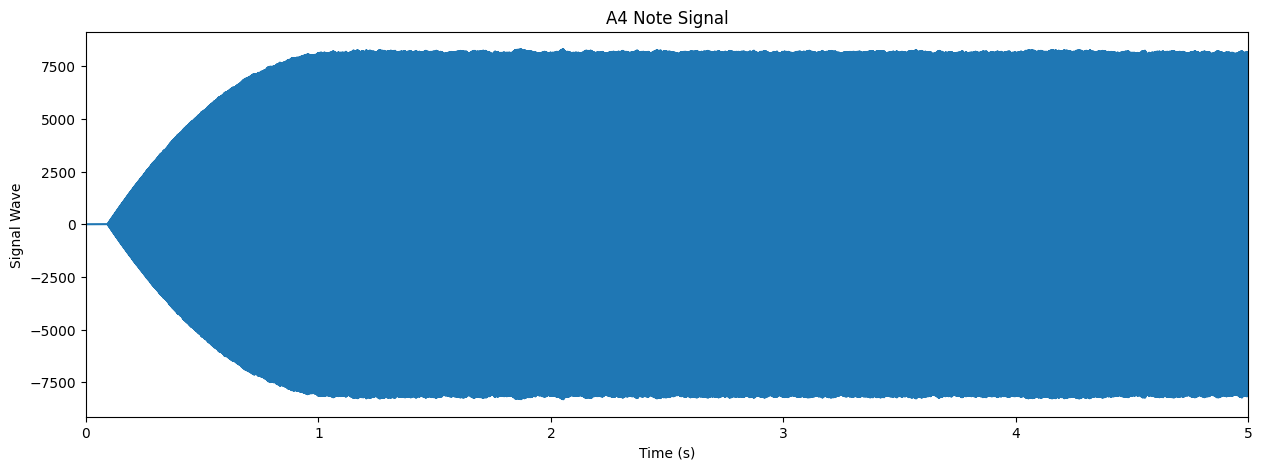

In [16]:
obj = wave.open('A4.wav', 'rb')

n_channels = obj.getnchannels()
sample_freq = obj.getframerate()
n_samples = obj.getnframes()
signal_wave = obj.readframes(n_samples)
t_audio = n_samples/sample_freq

obj.close()

print(t_audio,' s')

signal_array = np.frombuffer(signal_wave, dtype=np.int16)

if n_channels > 1: ## pretvaram u mono ako je stereo
    signal_array = signal_array.reshape(-1, n_channels)
    y = signal_array[:, 0]  
else:
    y = signal_array


times = np.linspace(0, t_audio, num=len(y), endpoint=False)

plt.figure(figsize=(15, 5))
plt.plot(times, y)
plt.title('A4 Note Signal')
plt.ylabel('Signal Wave')
plt.xlabel('Time (s)')
plt.xlim(0, t_audio)
plt.show()

## Frekvencijska analiza signala (FFT)

Iako vremenski prikaz signala pokazuje promjenu amplitude kroz vrijeme, iz njega nije moguće direktno vidjeti koje frekvencije ili tonovi čine audio signal.

Za analizu frekvencijskog sadržaja signala koristi se Fourierova transformacija. U ovom radu koristi se brza Fourierova transformacija (FFT – Fast Fourier Transform), koja omogućuje pretvaranje signala iz vremenske domene u frekvencijsku domenu.

FFT algoritam analizira signal i određuje koje frekvencije su prisutne u promatranom segmentu te kolika je njihova amplituda. Rezultat transformacije je frekvencijski spektar koji prikazuje jačinu pojedinih frekvencija u signalu.

Na dobivenom grafu frekvencijskog spektra x-os predstavlja frekvenciju u Hertzima (Hz), dok y-os predstavlja amplitudu pojedine frekvencije. Frekvencija s najvećom amplitudom predstavlja dominantnu frekvenciju u analiziranom segmentu signala.

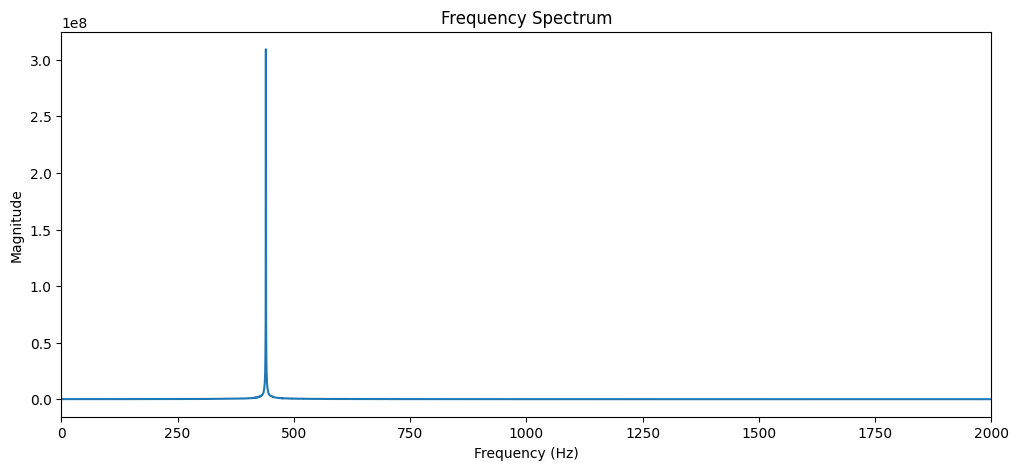

Dominantna frekvencija je:  440.0  Hz


In [17]:
sample = y[0 : int(sample_freq * 2)]  # uzimamo prvih 2 sekunda

# FFT
fft_values = np.fft.fft(sample)
fft_magnitude = np.abs(fft_values)

# frekvencijska os
freqs = np.fft.fftfreq(len(fft_values), 1/sample_freq)

# uzimamo samo pozitivne frekvencije
positive_freqs = freqs[:len(freqs)//2]
positive_magnitude = fft_magnitude[:len(freqs)//2]

plt.figure(figsize=(12,5))
plt.plot(positive_freqs, positive_magnitude)
plt.title("Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 2000)   # fokus na prve frekvencije
plt.show()

dominant_freq = positive_freqs[np.argmax(positive_magnitude)]
print("Dominantna frekvencija je: " , dominant_freq , " Hz")

U sljedeém primjeru radim istu stvar kao i u prošlom, samo umjesto jednoga tona ću koristiti pjesmu (Mostovi - Desna noga jednoroga). 

247.1067573696145  s


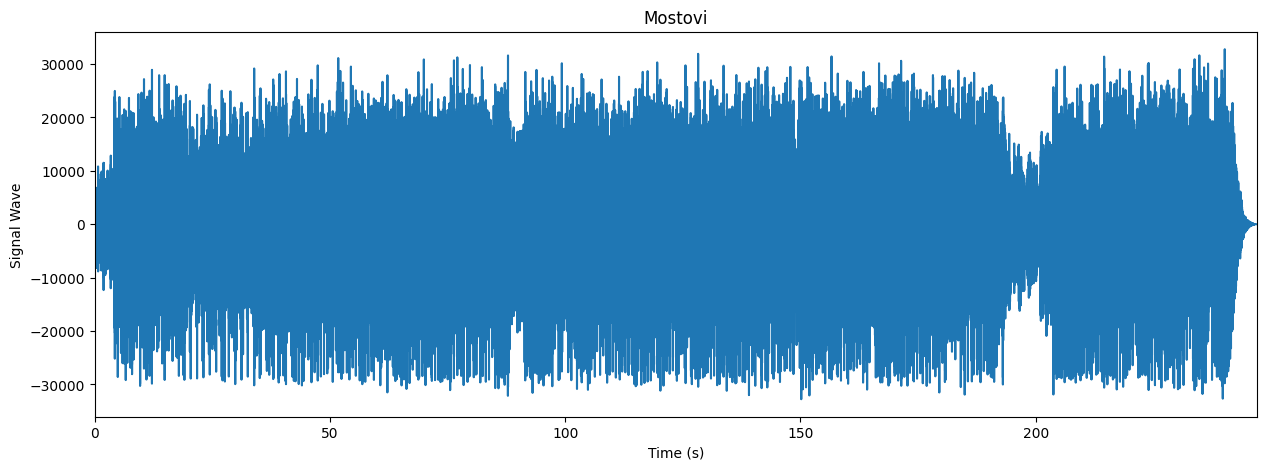

In [18]:
obj = wave.open('Mostovi.wav', 'rb')

n_channels = obj.getnchannels()
sample_freq = obj.getframerate()
n_samples = obj.getnframes()
signal_wave = obj.readframes(n_samples)
t_audio = n_samples/sample_freq

obj.close()

print(t_audio,' s')

signal_array = np.frombuffer(signal_wave, dtype=np.int16)

if n_channels > 1: ## pretvaram u mono ako je stereo
    signal_array = signal_array.reshape(-1, n_channels)
    y = signal_array[:, 0]  
else:
    y = signal_array


times = np.linspace(0, t_audio, num=len(y), endpoint=False)

plt.figure(figsize=(15, 5))
plt.plot(times, y)
plt.title('Mostovi')
plt.ylabel('Signal Wave')
plt.xlabel('Time (s)')
plt.xlim(0, t_audio)
plt.show()



Vidimo kako je waveform dosta raštrkaniji nego u primjeru u kojemu smo imali samo jedan ton.

U ovom primjeru nalizira se segment iz pjesme između 2 i 2.1 sekunde pjesme. Analiza kraćih vremenskih segmenata omogućuje promatranje promjena frekvencijskog sadržaja kroz vrijeme, što je važno za kasnije prepoznavanje glazbenih tonova i akorda.

U pjesmi Mostovi se u segmentu od 2 do 2.1 sekunde svira akord G dur, koji sadrži note G, A, B, C, D, E i F#. Graf frekvencijskog spektra bi trebao pokazivati skokove aplitude na frekvencijama tih tonova.

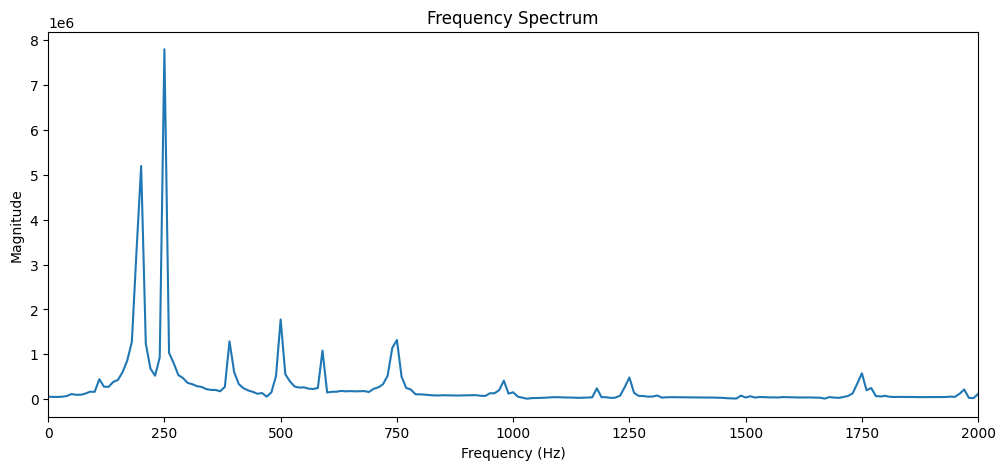

Pet najdominantnijih frekvencija:
1. 250.00 Hz (magnituda: 7800457.49)
2. 200.00 Hz (magnituda: 5198435.00)
3. 190.00 Hz (magnituda: 3294876.97)
4. 500.00 Hz (magnituda: 1777935.73)
5. 750.00 Hz (magnituda: 1319696.93)


In [19]:
sample = y[int(sample_freq * 2.0) : int(sample_freq * 2.1)]  

# FFT
fft_values = np.fft.fft(sample)
fft_magnitude = np.abs(fft_values)

# frekvencijska os
freqs = np.fft.fftfreq(len(fft_values), 1/sample_freq)

# uzimamo samo pozitivne frekvencije
positive_freqs = freqs[:len(freqs)//2]
positive_magnitude = fft_magnitude[:len(freqs)//2]

plt.figure(figsize=(12,5))
plt.plot(positive_freqs, positive_magnitude)
plt.title("Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 2000)   # fokus na prve frekvencije
plt.show()

search_magnitude = positive_magnitude.copy()
search_magnitude[0] = 0

# indeksi 3 najveće magnitude
top5_idx = np.argsort(search_magnitude)[-5:][::-1]

print("Pet najdominantnijih frekvencija:")
for i, idx in enumerate(top5_idx, 1):
    print(f"{i}. {positive_freqs[idx]:.2f} Hz (magnituda: {positive_magnitude[idx]:.2f})")


Mjerimo 5 najdominantnijih frekvencija u segmentu i dobijamo 250 Hz (B3), 200 Hz (G3), 190 Hz (F#3), 500 Hz (B4) i 750 (F#5). Vidimo da su svi tonovi dio G dur skale čime možemo predpostaviti da je program dobro odredio frekvencije.

## Segmentacija i podjela na prozore

Signal će se podijeliti u kratke vremenske prozore fiksne duljine uz djelomično preklapanje između prozora kako bi se osigurala stabilnija analiza.

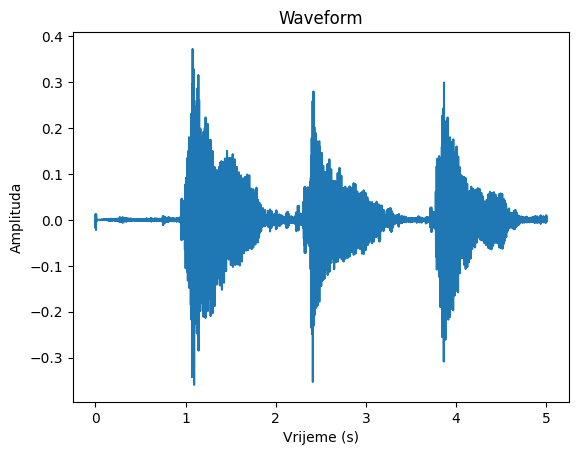

In [2]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt

sample_rate, signal = wav.read('recording_20260519_165641.wav')

if len(signal.shape) > 1:         
    signal = signal.mean(axis=1)
    
    
    
# vrijeme (x-os)
time = np.arange(len(signal)) / sample_rate

# CRTANJE WAVEFORMA
plt.plot(time, signal)
plt.title("Waveform")
plt.xlabel("Vrijeme (s)")
plt.ylabel("Amplituda")
plt.show()
    


Na svaki segment primijenit će se prozorska funkcija (npr. Hann prozor) kako bi se smanjili neželjeni efekti prilikom primjene Fourierove transformacije. Za svaki vremenski prozor izračunat će se frekvencijski spektar pomoću FFT algoritma. Dobiveni rezultati koristit će se za daljnju analizu harmonijskih karakteristika signala.

U primjeru ću ispisati par degmenata i prikazati ih na grafu.

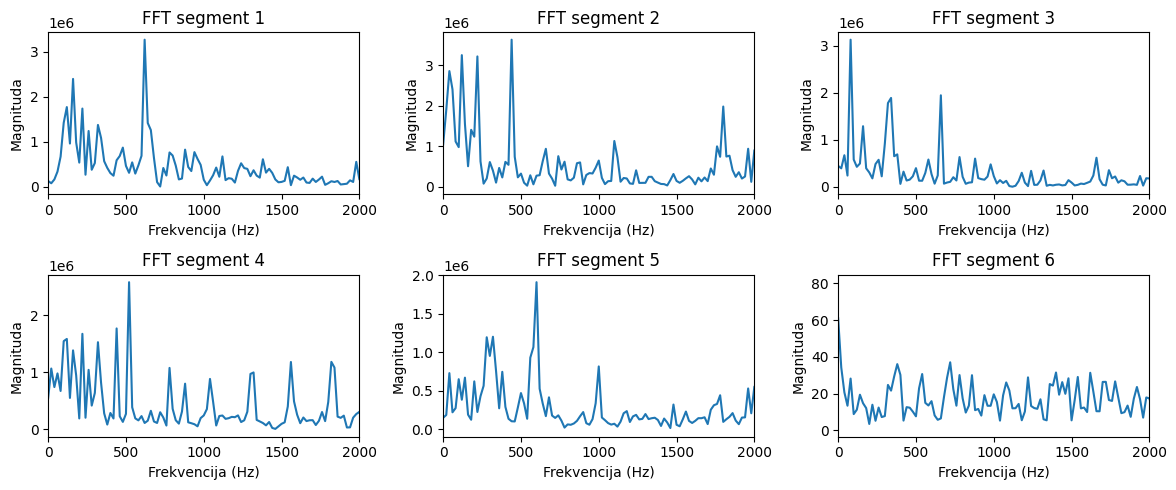

In [21]:
window_size = int(0.05 * sample_rate)  # 50 ms
hop_size = window_size  # BEZ overlapa 

segments = []

for start in range(0, len(signal) - window_size, hop_size):
    segment = signal[start:start + window_size]
    segments.append(segment)

segments = np.array(segments)

fft_segments = []

for segment in segments:
    fft_result = np.fft.rfft(segment)
    magnitude = np.abs(fft_result)
    fft_segments.append(magnitude)

fft_segments = np.array(fft_segments)



# frekvencijska os za rFFT
freqs = np.fft.rfftfreq(window_size, d=1/sample_rate)


seg1 = fft_segments[fft_segments.shape[0] // 6 ]  # prvi segment
seg2 = fft_segments[fft_segments.shape[0] // 6 * 2]  # drugi segment
seg3 = fft_segments[fft_segments.shape[0] // 6 * 3]  # treći segment
seg4 = fft_segments[fft_segments.shape[0] // 6 * 4]  # četvrti segment
seg5 = fft_segments[fft_segments.shape[0] // 6 * 5]  # peti segment
seg6 = fft_segments[-1]  # zadnji segment

plt.figure(figsize=(12, 5))

plt.subplot(2, 3, 1)
plt.plot(freqs, seg1)
plt.title("FFT segment 1")
plt.xlabel("Frekvencija (Hz)")
plt.ylabel("Magnituda")
plt.xlim(0, 2000)

plt.subplot(2, 3, 2)
plt.plot(freqs, seg2)
plt.title("FFT segment 2")
plt.xlabel("Frekvencija (Hz)")
plt.ylabel("Magnituda")
plt.xlim(0, 2000)

plt.subplot(2, 3, 3)
plt.plot(freqs, seg3)
plt.title("FFT segment 3")
plt.xlabel("Frekvencija (Hz)")
plt.ylabel("Magnituda")
plt.xlim(0, 2000)

plt.subplot(2, 3, 4)
plt.plot(freqs, seg4)
plt.title("FFT segment 4")
plt.xlabel("Frekvencija (Hz)")
plt.ylabel("Magnituda")
plt.xlim(0, 2000)

plt.subplot(2, 3, 5)
plt.plot(freqs, seg5)
plt.title("FFT segment 5")
plt.xlabel("Frekvencija (Hz)")
plt.ylabel("Magnituda")
plt.xlim(0, 2000)

plt.subplot(2, 3, 6)
plt.plot(freqs, seg6)
plt.title("FFT segment 6")
plt.xlabel("Frekvencija (Hz)")
plt.ylabel("Magnituda")
plt.xlim(0, 2000)

plt.tight_layout()
plt.show()

 

Svi grafivi izgledaju različito, ali su maksimalne magnitude na sličnim frekvencijama (što ima smisla jer se akordi u pjesmi ponavljaju). Dakle, možemo za svaki segment zaključiti na kojim frekvencijama se pojavljuje aplituda čime možemo pretpostaviti akorde u tim segmentima. 